In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10,CIFAR100


/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
transform = transforms.Compose([
    transforms.Resize([224,224]),
    transforms.ToTensor()
])          


In [3]:
cifar100_train = CIFAR100(root='./data', train=True, download=True, transform=transform)
cifar100_test = CIFAR100(root='./data', train=False, download=True, transform=transform)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
model_algo="alexnet"

In [5]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [6]:
images=CifarDataset(cifar100_train)
generator = torch.Generator()
generator.manual_seed(125)

size = len(images)
valid_size = int(0.2 * size)

train_size = int(size -valid_size)

trainset,validset = random_split(images, (train_size, valid_size), generator=generator)

In [7]:
valid_size

10000

In [8]:
train_size

40000

In [9]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

In [10]:
# model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
model_0 = torch.load(f'model_{model_algo}_0_18.pth')

In [11]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.6179550765633584, 0.8131)

In [12]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(1.5396165259361267, 0.5923)

In [13]:
r=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(0)
p=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)

In [14]:
each_accu=p
each_accu=each_accu.sort_values()
each_accu

seal           0.250633
otter          0.327366
mouse          0.368812
rabbit         0.408978
willow_tree    0.453865
                 ...   
sunflower      0.982368
orange         0.982587
chair          0.984962
wardrobe       0.990338
apple          0.995000
Length: 100, dtype: float64

In [15]:
each_f1=2*p*r/(p+r)
each_f1

apple            0.915995
aquarium_fish    0.959391
baby             0.733728
bear             0.522134
beaver           0.623877
                   ...   
whale            0.796834
willow_tree      0.584270
wolf             0.775648
woman            0.577099
worm             0.888312
Length: 100, dtype: float64

In [16]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
split_mode=('classaccu',30)

if(split_mode[0]=='classf1'):
    targetF=[x  for x in each_f1.nsmallest(split_mode[1]).index.map(trainset.dataset.classess)]
    split=(split_mode[0],targetF)
elif(split_mode[0]=='classaccu'):
    targetF=[x  for x in each_accu.nsmallest(split_mode[1]).index.map(trainset.dataset.classess)]
    split=(split_mode[0],targetF)
else:
    split=split_mode

indexF,indexT=split_data(model_0,train_dl,split)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)

Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)

len(indexF),len(indexT)

(12001, 27999)

In [17]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split)
len(indexF_v),len(indexT_v)

(2999, 7001)

In [18]:
# d_data,d_target=decision_split(train_dl,model_0)
# d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [19]:
# decisionset=DecisionDataset(d_data,d_target)
# decisionset_v=DecisionDataset(d_v_data,d_v_target)

In [20]:
class_counts = [0, 0]
for _,_,label,_ in trainset:
    class_counts[label] +=1

In [21]:
# 计算每个类别的权重
class_weights = [1.0 / count for count in class_counts]
weights = torch.FloatTensor(class_weights).cuda()

In [62]:
             
#將模型建立框架後並訓練
def model_train(model_algo,train_dl,valid_dl,data_name,epochs,model_0=None):

    if(data_name=="decision"):
        # model=model_create(model_algo,data_name,2)
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,2)

    elif(data_name=='T'or data_name=='F'):
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,len(train_dl.dataset.dataset.classes))

    else:
        model=model_create(model_algo,data_name,len(train_dl.dataset.dataset.classes))

    if(model_algo=='googlenet' or model_algo=='resnet18' or model_algo=='inception_v3' ):
        model_fc_layer=model.fc
    else:
        model_fc_layer=model.classifier[6]


    if(data_name=="decision"):
        
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss() 
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)

    elif(data_name=='0'):
        optim = torch.optim.Adam(model.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss() 
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)

    else:   

        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    torch.cuda.empty_cache() 
    return model


Epoch=0,train_loss=0.3086994839549065,train_accu=0.861075
Epoch=0,valid_loss=0.39556394658088684,valid_accu=0.8077
0
Epoch=1,train_loss=0.27159498872160914,train_accu=0.883
Epoch=1,valid_loss=0.37783120861053465,valid_accu=0.8207
0
Epoch=2,train_loss=0.24863283529877664,train_accu=0.897625
Epoch=2,valid_loss=0.37163410181999207,valid_accu=0.8262
0
Epoch=3,train_loss=0.23321755847930908,train_accu=0.90375
Epoch=3,valid_loss=0.3680850050926209,valid_accu=0.8309
0
Epoch=4,train_loss=0.21866061526834965,train_accu=0.914175
Epoch=4,valid_loss=0.36226823835372923,valid_accu=0.8334
0
Epoch=5,train_loss=0.21012777101397515,train_accu=0.915375
Epoch=5,valid_loss=0.36418907113075255,valid_accu=0.8328
Epoch=6,train_loss=0.20047694545090197,train_accu=0.92175
Epoch=6,valid_loss=0.36315378165245055,valid_accu=0.8377
0
Epoch=7,train_loss=0.19256996150016784,train_accu=0.9252
Epoch=7,valid_loss=0.35963322262763975,valid_accu=0.8396
0
Epoch=8,train_loss=0.1869519335359335,train_accu=0.927925
Epoch=8,v

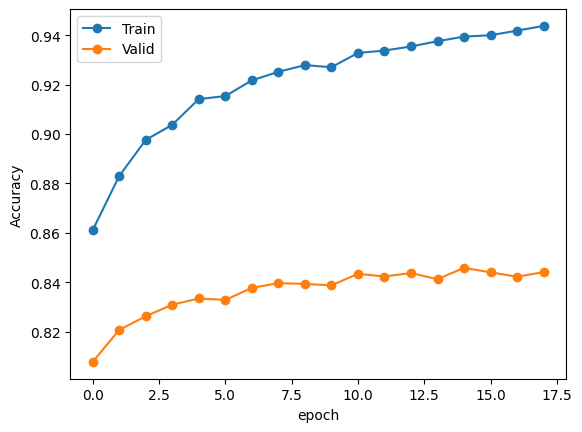

In [23]:
from torchsampler import ImbalancedDatasetSampler
# decision_dl = DataLoader(decisionset, batch_size=32)
# # decision_dl = DataLoader(decisionset, batch_size=32,sampler=ImbalancedDatasetSampler(decisionset))
# decision_v_dl = DataLoader(decisionset_v, batch_size=32)
# train_dl=DataLoader(trainset, batch_size=32,sampler=ImbalancedDatasetSampler(trainset))
model_decision=model_train(model_algo,train_dl,valid_dl,"decision",70,model_0=model_0)

In [24]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)

Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

Epoch=0,train_loss=0.4704210838082305,train_accu=0.8918889960355727
Epoch=0,valid_loss=1.1075110172922313,valid_accu=0.6937580345664905
0
Epoch=1,train_loss=0.33965382808263594,train_accu=0.9065680917175614
Epoch=1,valid_loss=1.0616016758797664,valid_accu=0.7078988715897729
0
Epoch=2,train_loss=0.2978237916946053,train_accu=0.9147112396871316
Epoch=2,valid_loss=1.0564961587338937,valid_accu=0.7144693615197829
0
Epoch=3,train_loss=0.2784239155717644,train_accu=0.9186756669881068
Epoch=3,valid_loss=1.0617699404475247,valid_accu=0.7161834023710898
0
Epoch=4,train_loss=0.2648108793365567,train_accu=0.9206757384192292
Epoch=4,valid_loss=1.0694913385663947,valid_accu=0.7167547493215255
0
Epoch=5,train_loss=0.25614536051780157,train_accu=0.9227472409728918
Epoch=5,valid_loss=1.0943253174958407,valid_accu=0.7180402799600057
0
Epoch=6,train_loss=0.24224864063256468,train_accu=0.9277117039894281
Epoch=6,valid_loss=1.0795462572852164,valid_accu=0.7223253820882731
0
Epoch=7,train_loss=0.2290634715

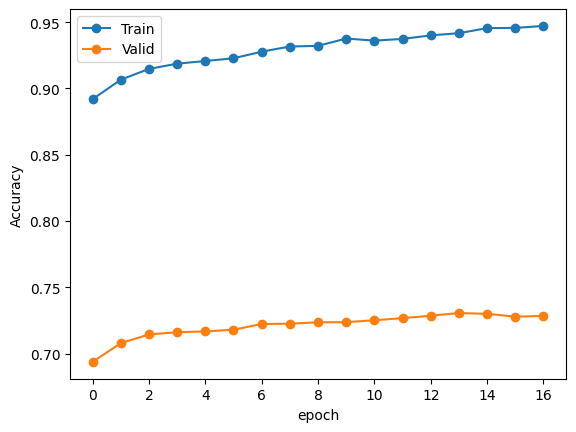

In [63]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70,model_0=model_0)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

Epoch=0,train_loss=0.965876559040644,train_accu=0.7338555120406632
Epoch=0,valid_loss=1.4968729318877625,valid_accu=0.5341780593531177
0
Epoch=1,train_loss=0.7380689441656115,train_accu=0.7700191650695776
Epoch=1,valid_loss=1.3893295738767806,valid_accu=0.557519173057686
0
Epoch=2,train_loss=0.6744633920986784,train_accu=0.779268394300475
Epoch=2,valid_loss=1.3881490908292342,valid_accu=0.5641880626875625
0
Epoch=3,train_loss=0.6253477625127296,train_accu=0.794433797183568
Epoch=3,valid_loss=1.3660492354053066,valid_accu=0.56918972990997
0
Epoch=4,train_loss=0.6009268231274595,train_accu=0.8006832763936339
Epoch=4,valid_loss=1.3736668429441474,valid_accu=0.5701900633544514
0
Epoch=5,train_loss=0.5760705875223969,train_accu=0.8064327972668944
Epoch=5,valid_loss=1.3773585561515094,valid_accu=0.5728576192064021
0
Epoch=6,train_loss=0.5685826093380615,train_accu=0.8092658945087909
Epoch=6,valid_loss=1.395139011473368,valid_accu=0.5795265088362788
0
Epoch=7,train_loss=0.5490577608215323,tra

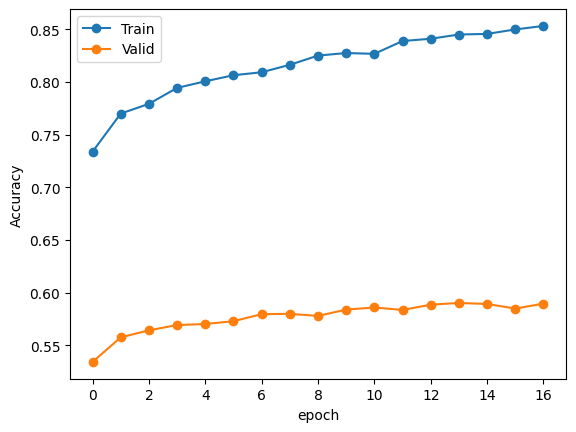

In [65]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70,model_0=model_0)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [27]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,train_dl,len(trainset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.16108643394634128, 0.939475)

In [28]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,valid_dl,len(validset),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.3546705725431442, 0.8458)

In [29]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.19066658635970385, 0.9502839387120968)

In [30]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.3778613577404774, 0.8901758186817765)

In [31]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(1.0602642259603228, 0.72403942293958)

In [32]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(1.3637819301291043, 0.5981993997999333)

In [69]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum

(0.2784654277473688, 0.9127, 12001)

In [68]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(1.1928956621170044, 0.6885, 2999)

In [66]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision,decision_mode='model')
total_train_loss,total_train_accu,sum_F,sum_T

(1.7790930302143098, 0.859675, 12050, 27950)

In [67]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision,decision_mode='model')
total_valid_loss,total_valid_accu,sum_F,sum_T

(4.709009386062622, 0.606, 2955, 7045)

In [70]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [71]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_with_perfect_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
print(f'split_mode = {split}')
df

split_mode = ('classaccu', [72, 55, 50, 65, 96, 98, 80, 10, 25, 35, 3, 92, 4, 11, 32, 59, 40, 2, 67, 44, 63, 46, 95, 64, 47, 90, 57, 93, 73, 18])


,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.617955,0.813100,1.539617,0.592300
1,Model_Decision,0.161086,0.939475,0.354671,0.845800
2,Model_T,0.190667,0.950284,1.060264,0.724039
3,Model_F,0.377861,0.890176,1.363782,0.598199
4,Total_Model,1.779093,0.859675,4.709009,0.606000
5,Total_Model_with_perfect_decision,0.278465,0.912700,1.192896,0.688500


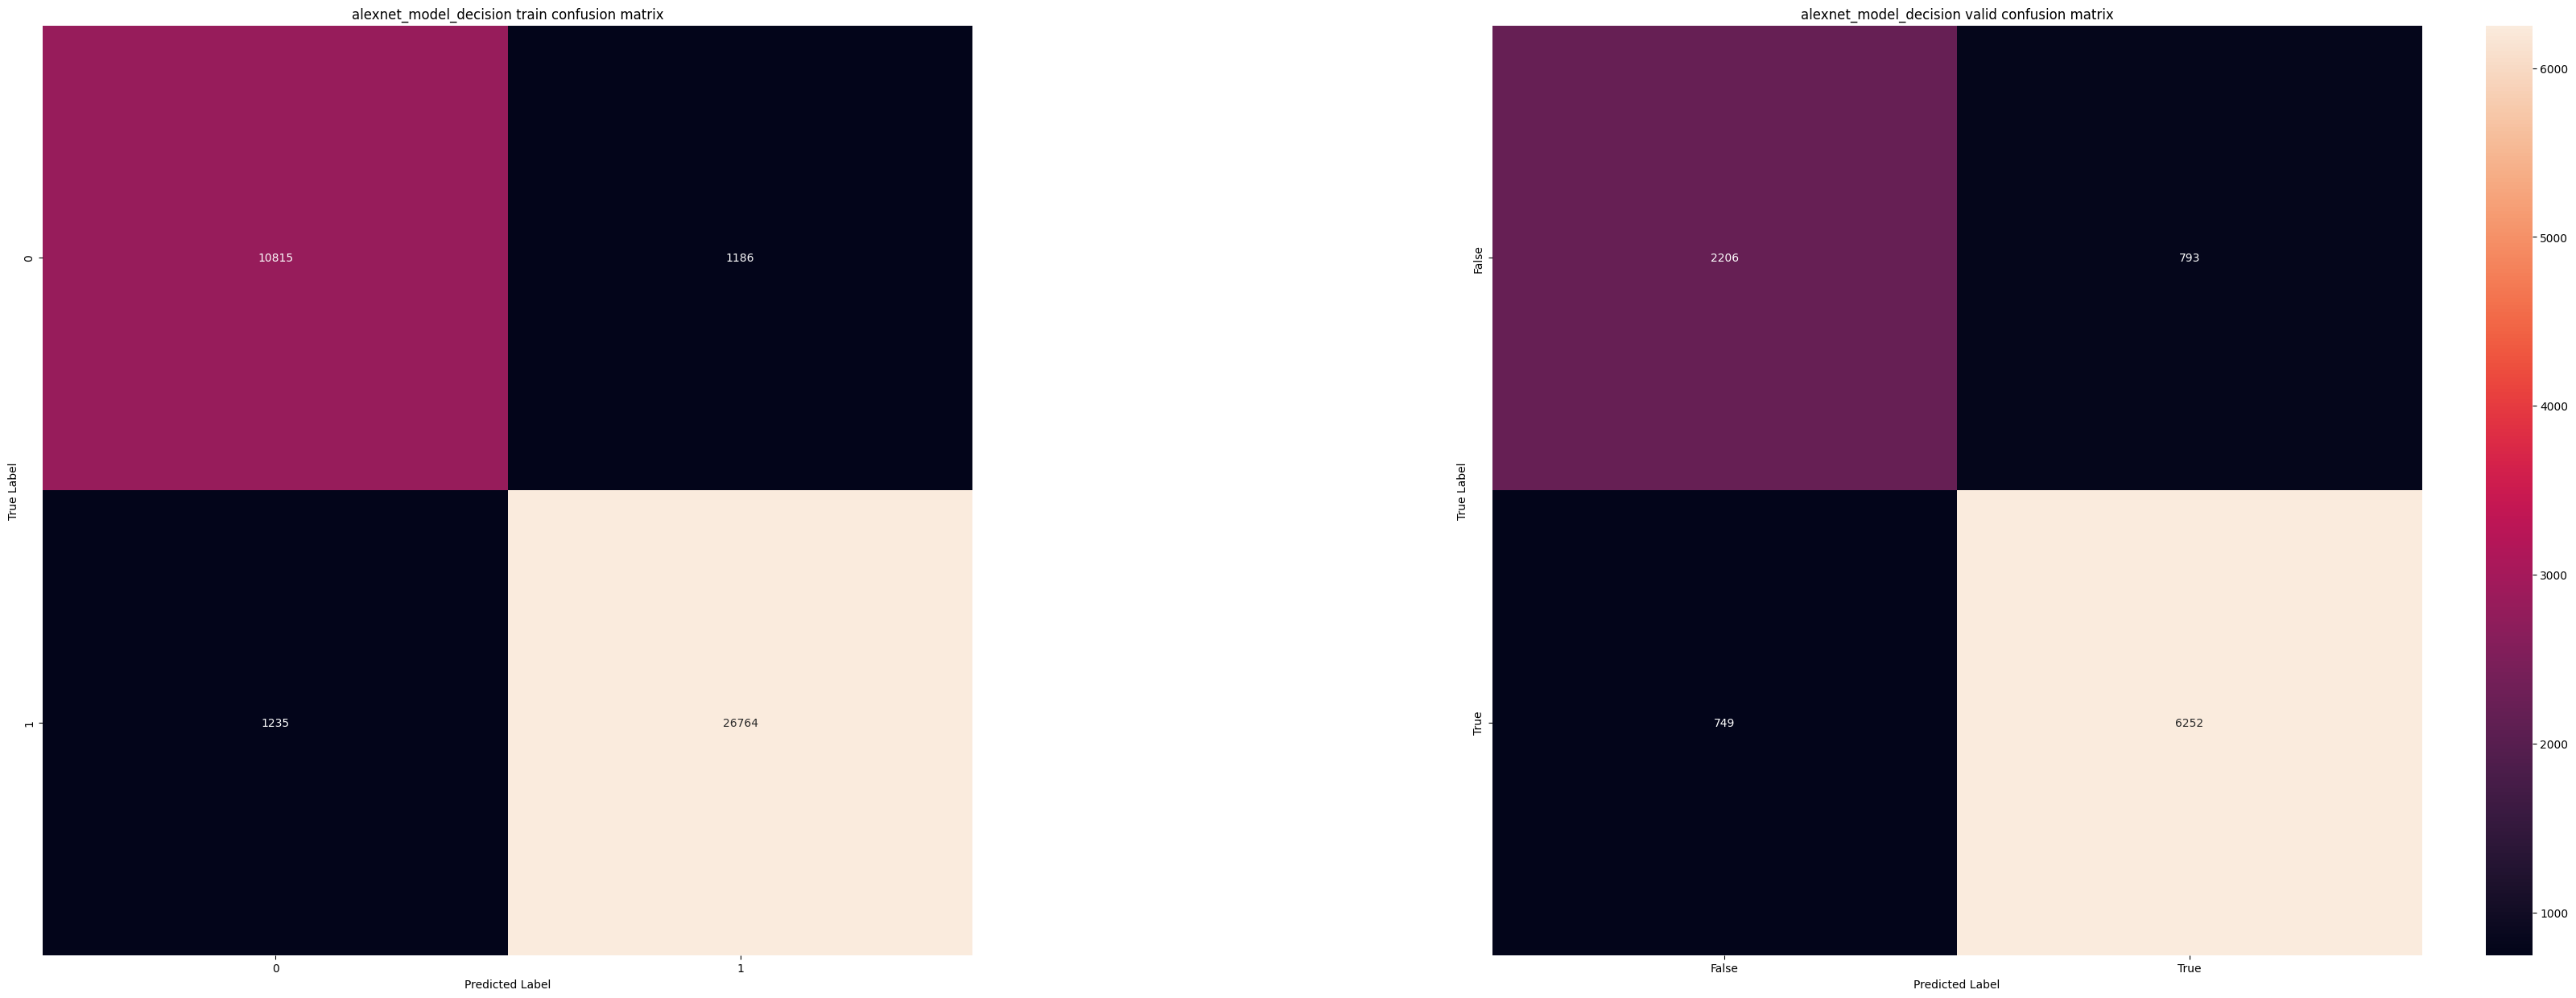

In [72]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

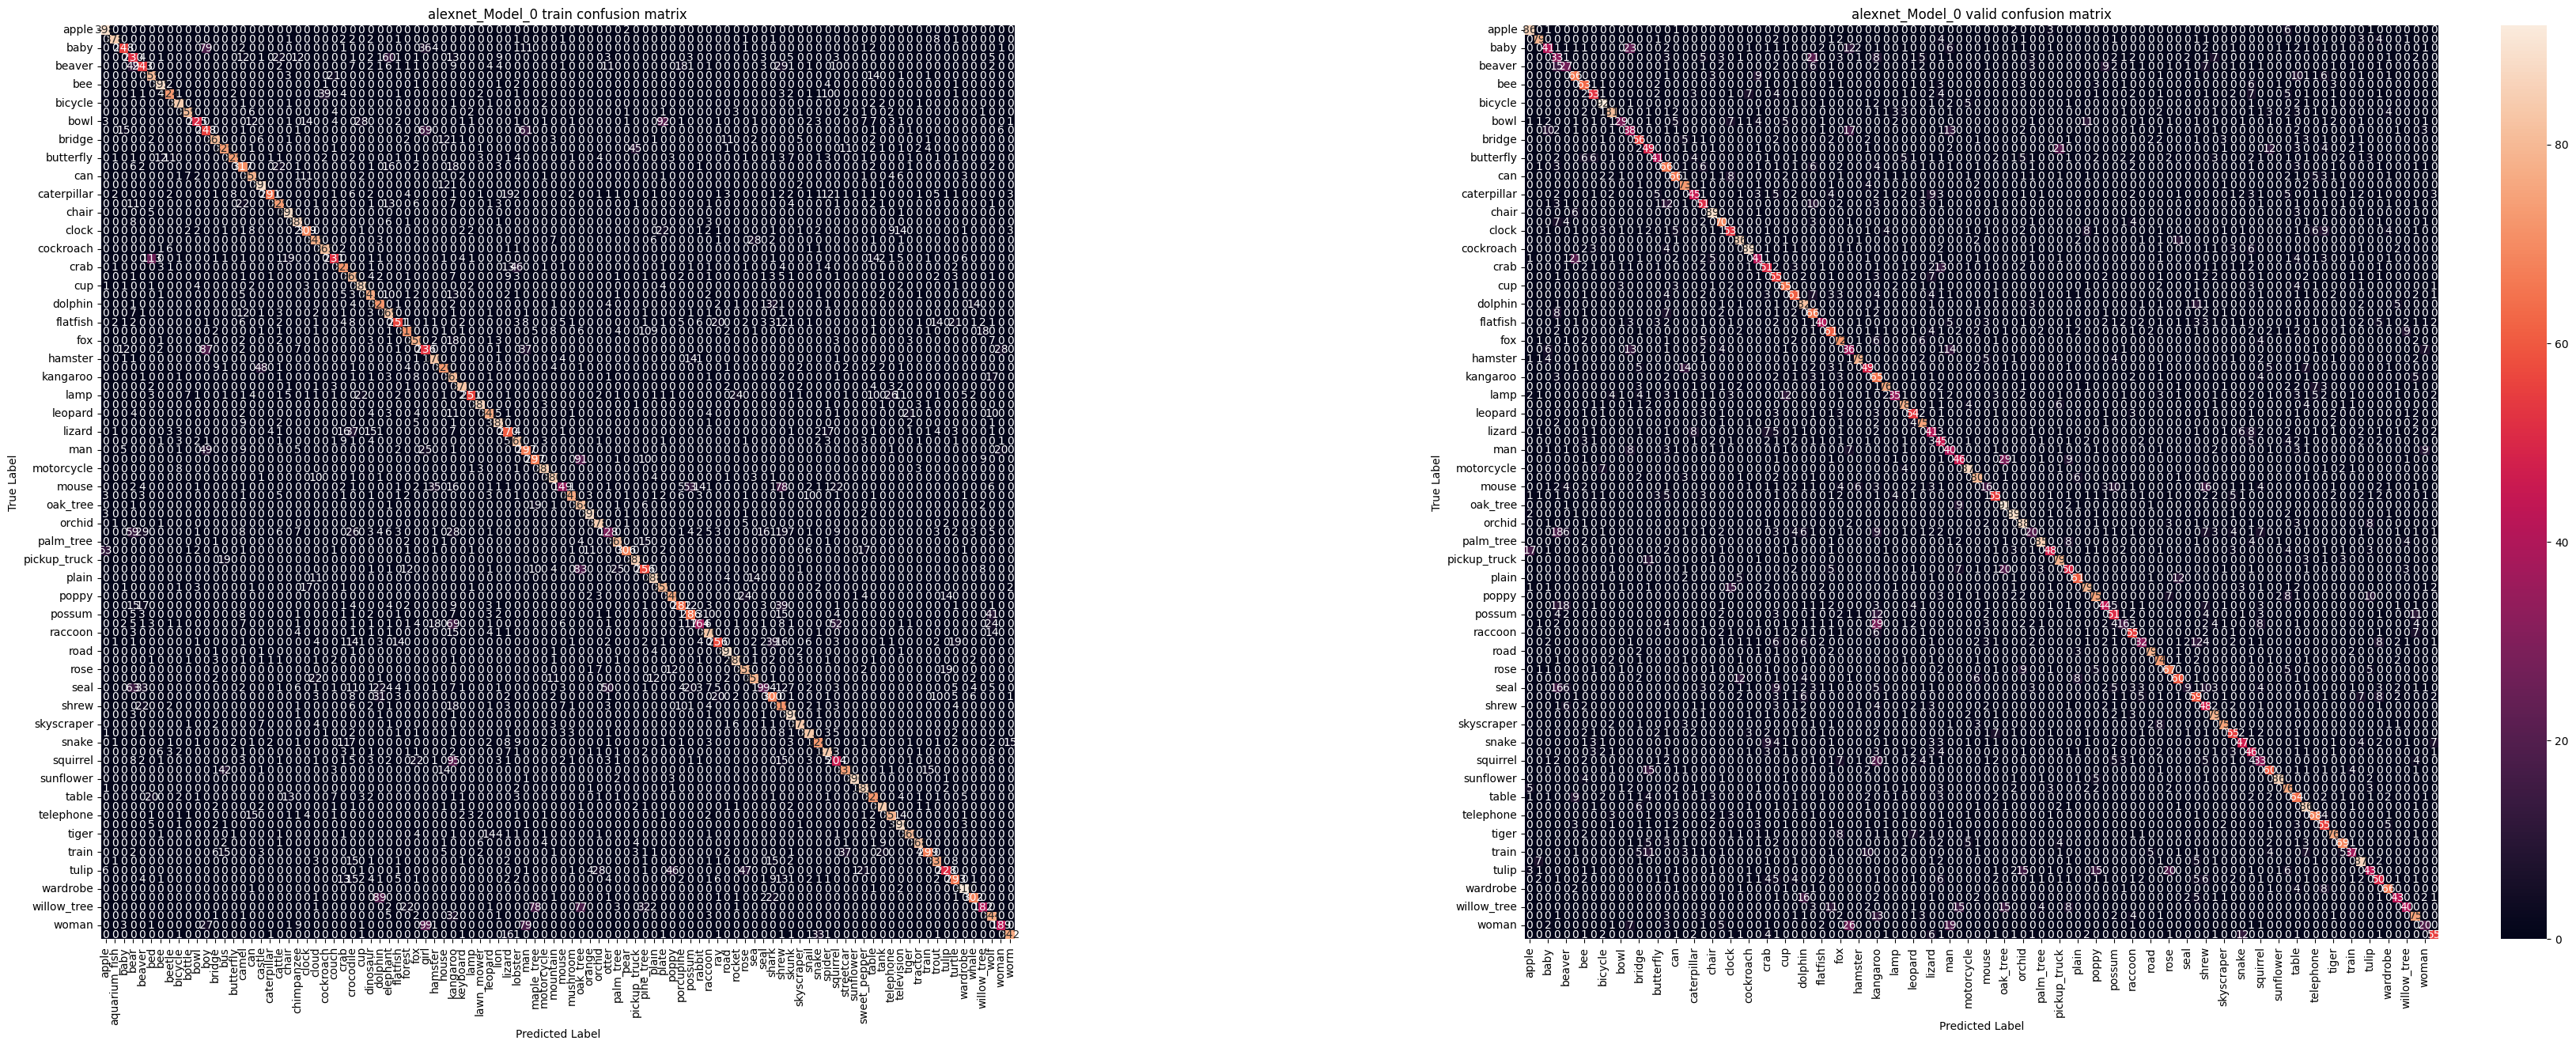

In [73]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

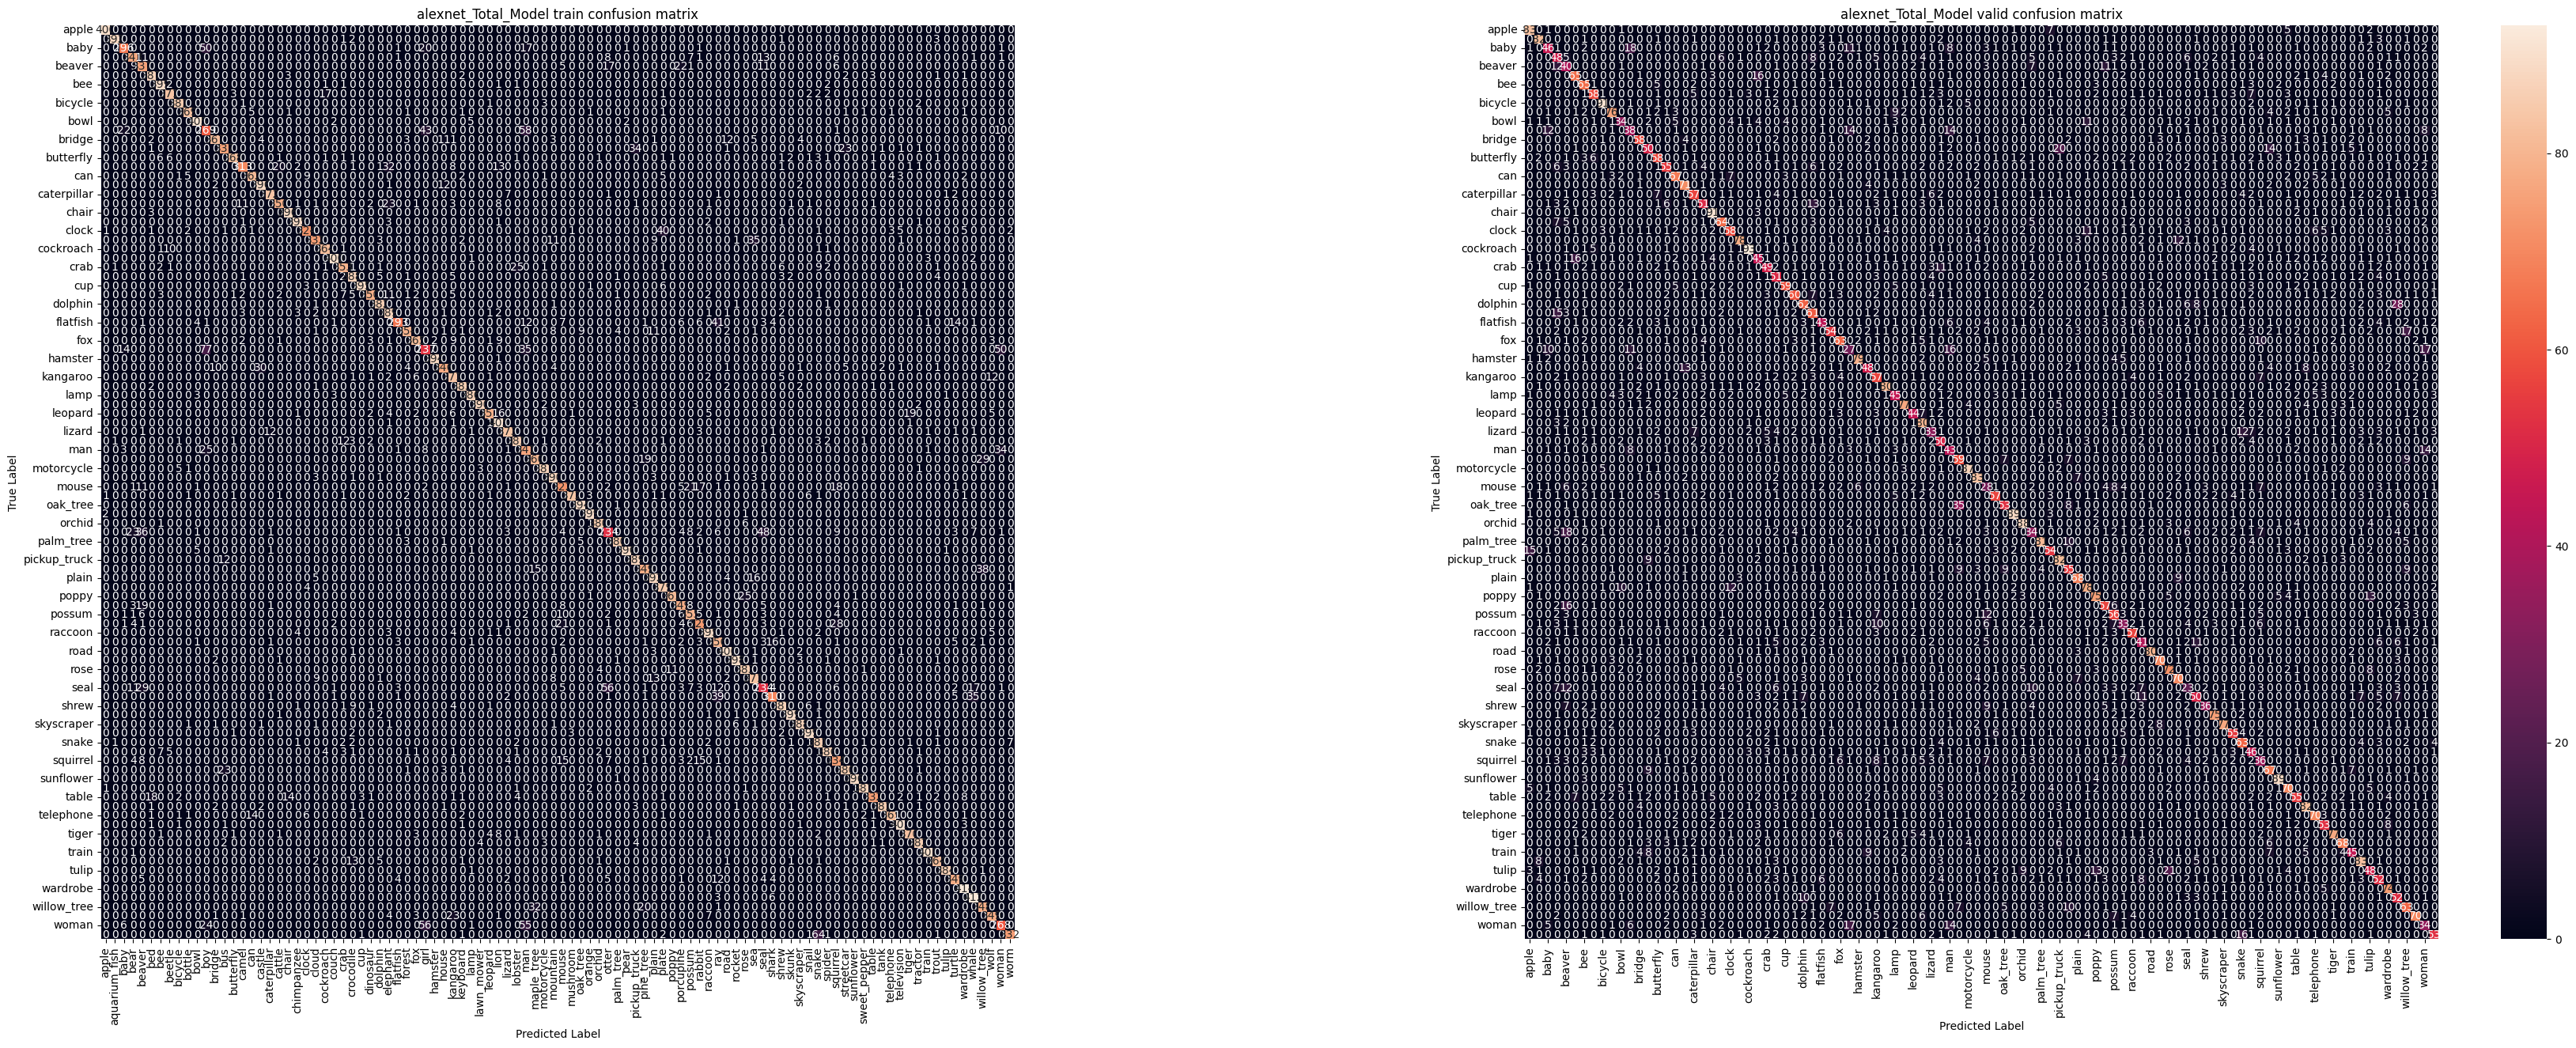

In [74]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

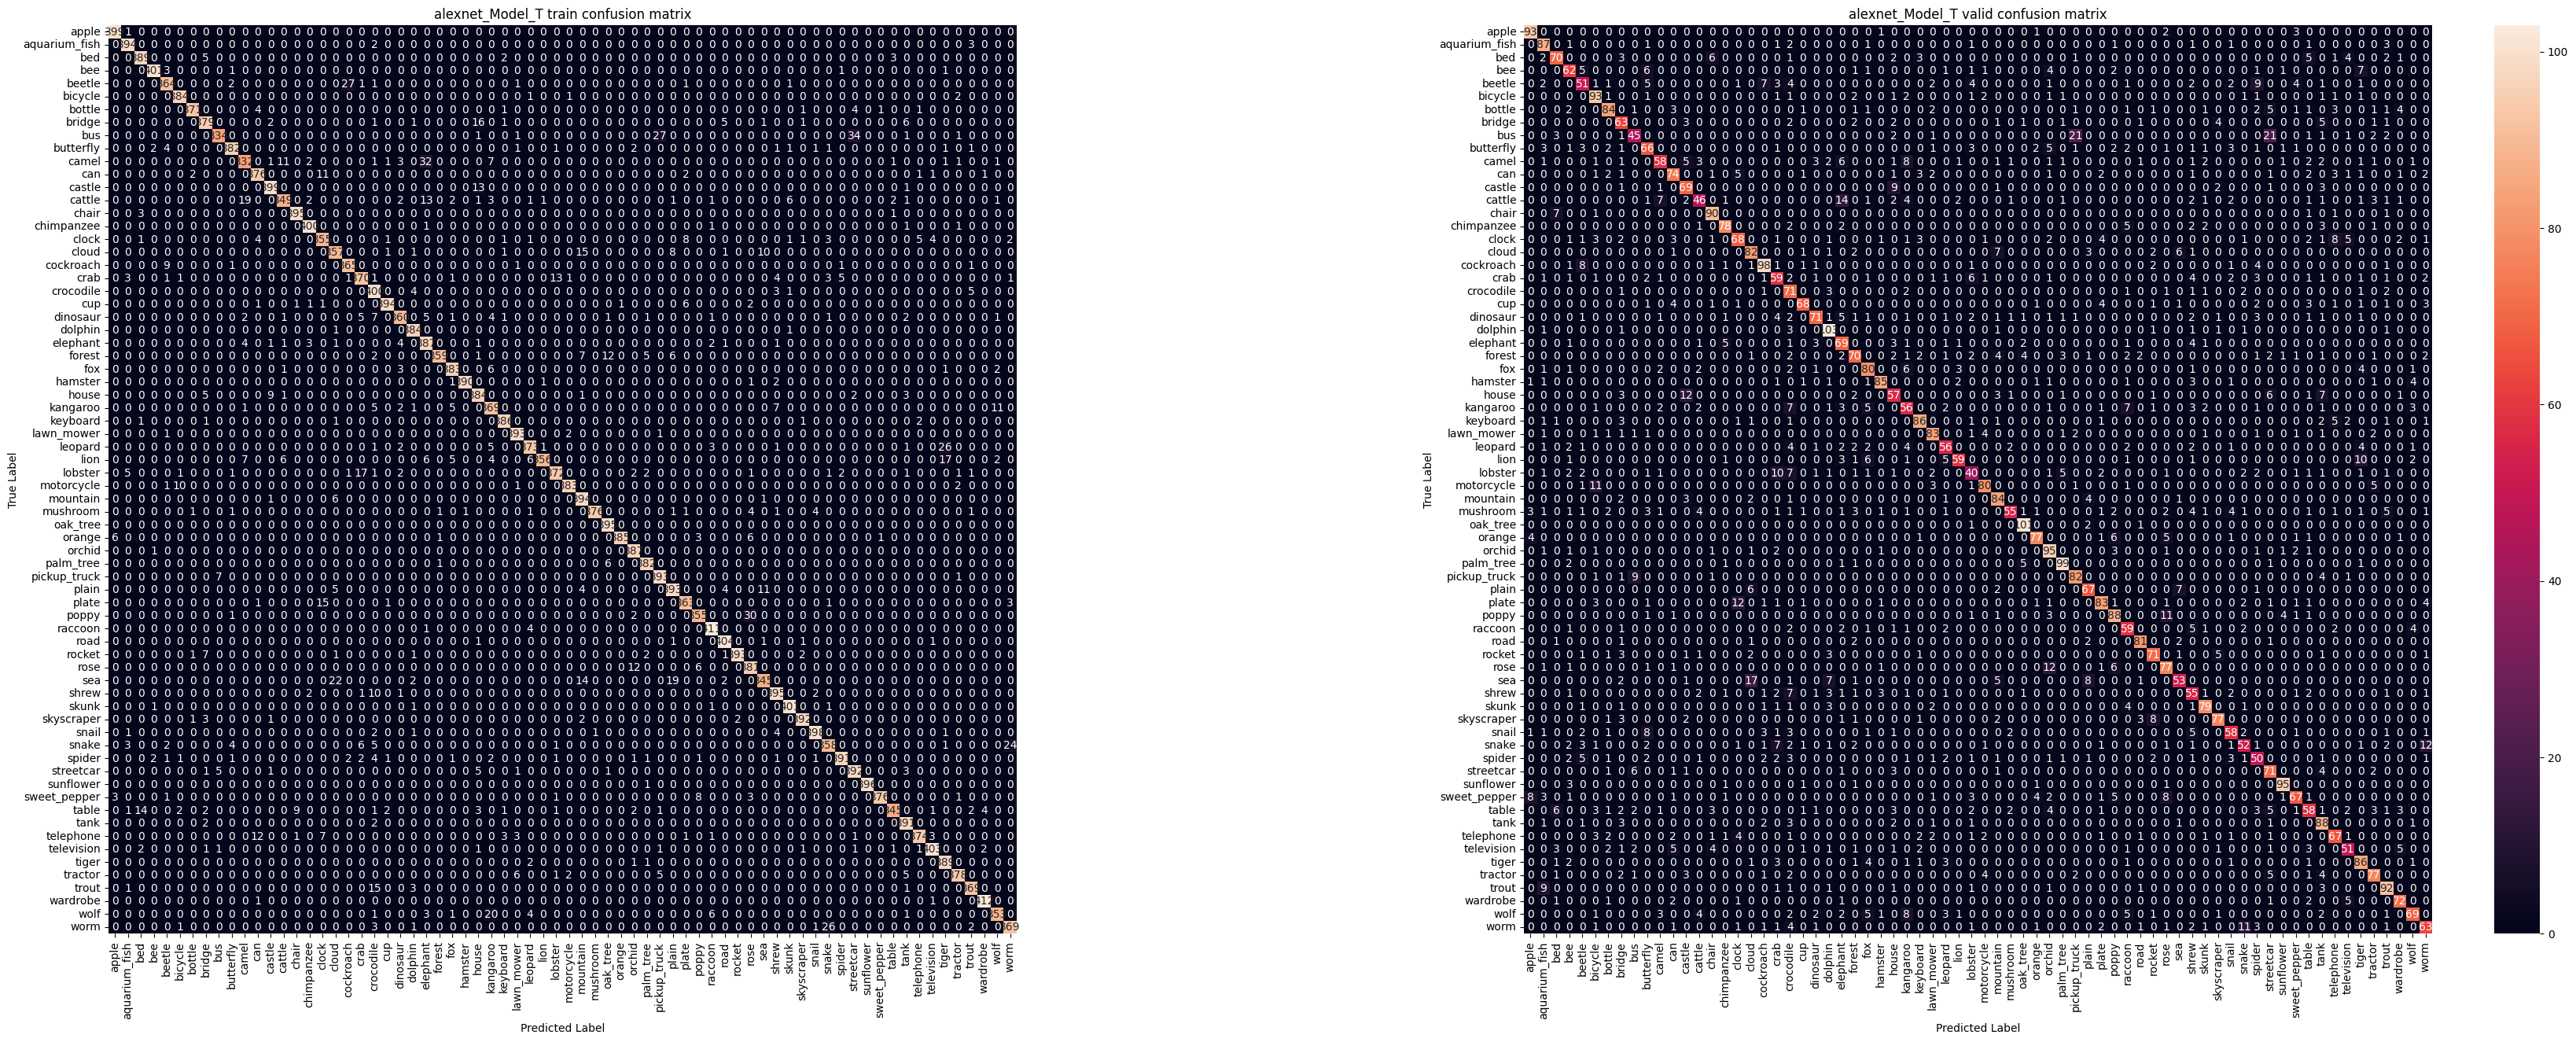

In [75]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

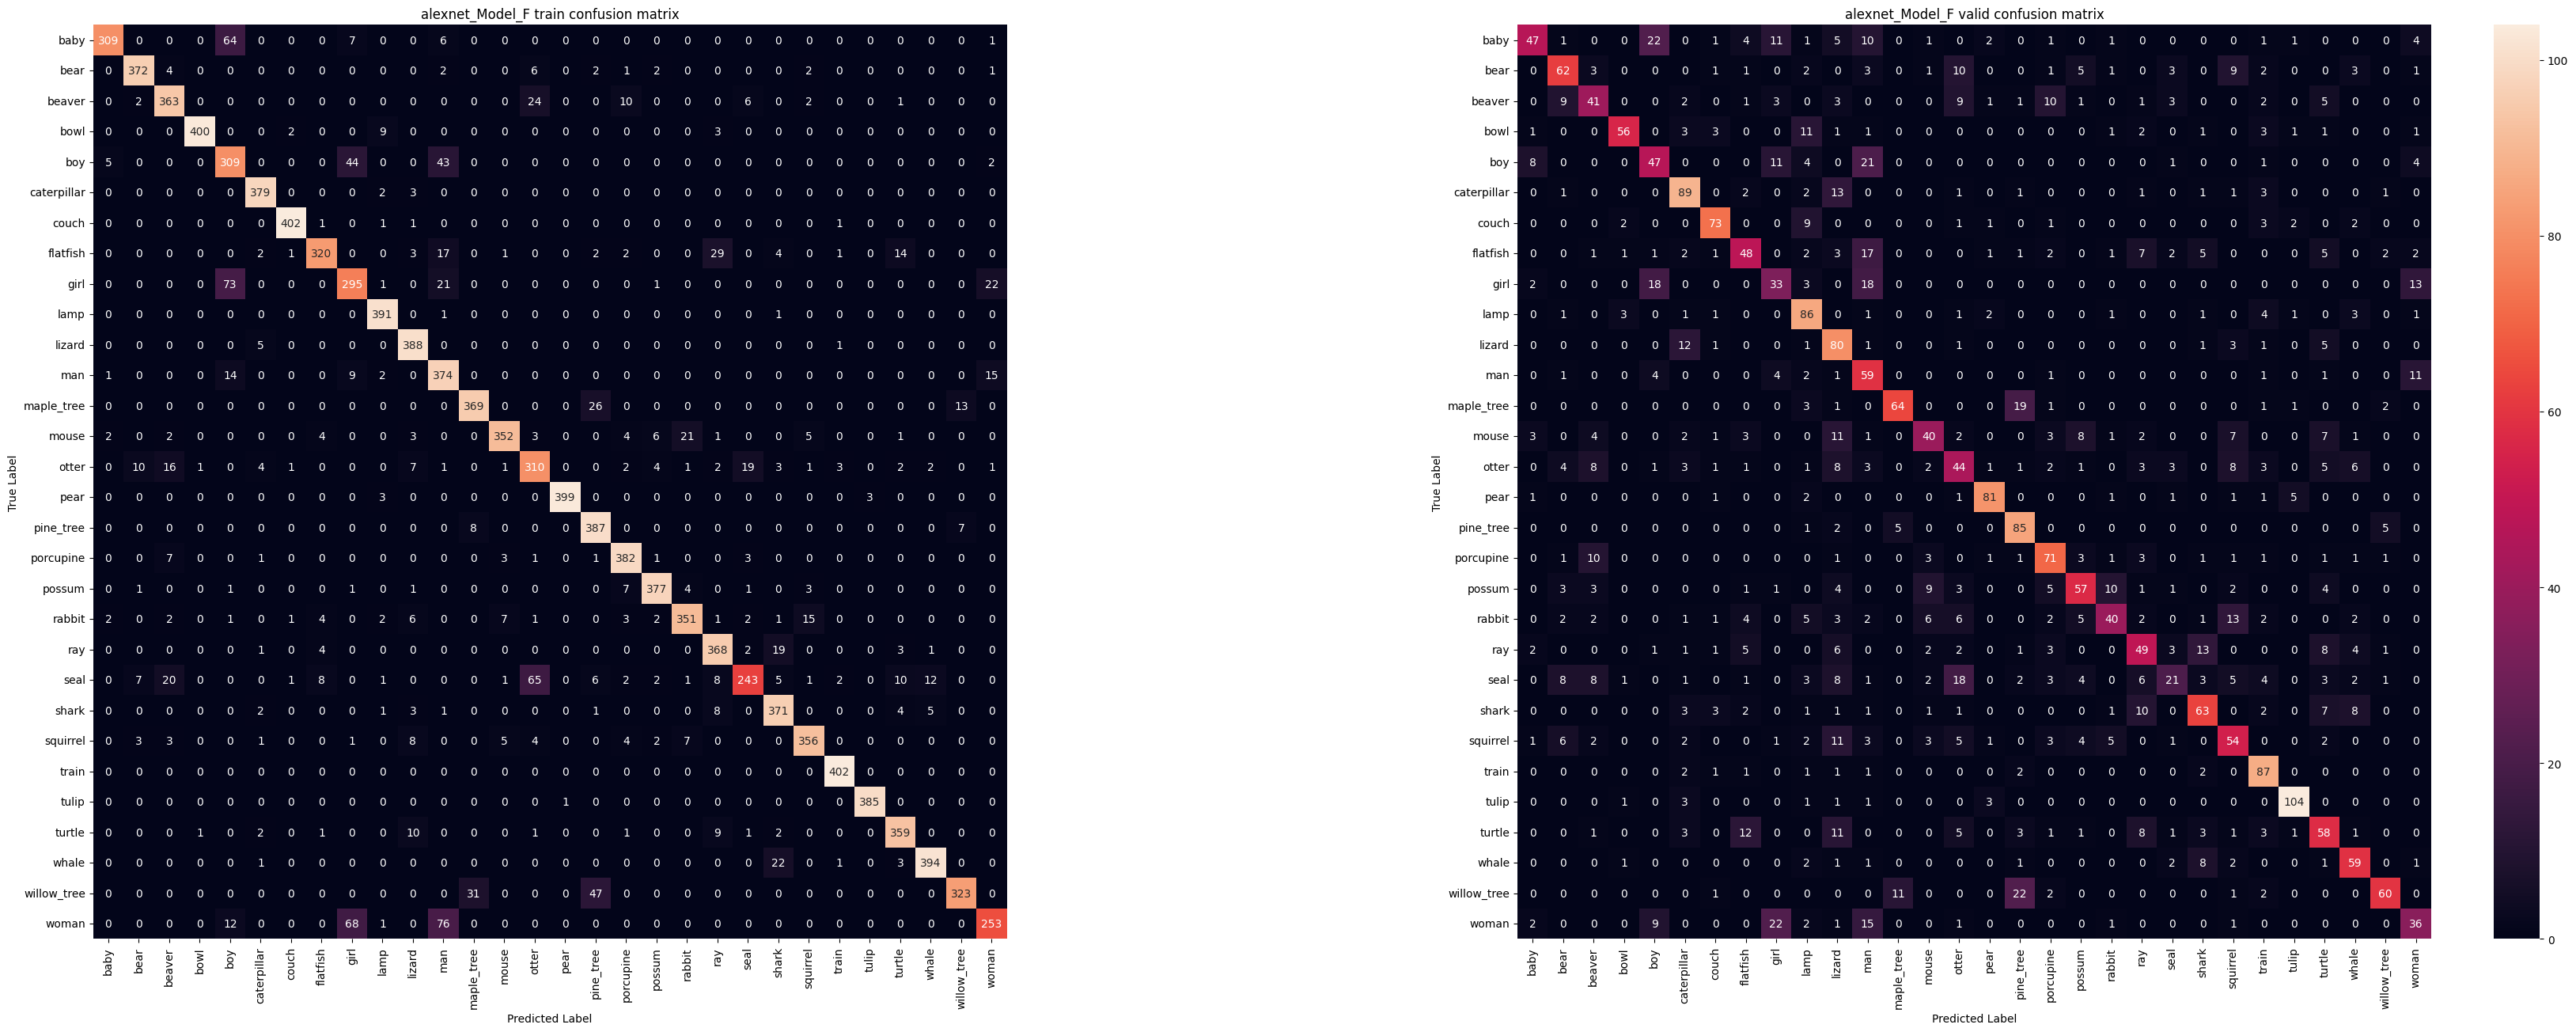

In [76]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [77]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,_,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.dataset.flag[idx]

                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [78]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,28243,7,18,7,7,0.998866,0.999999,0.999952,1.000000,False,True,True,True,True
1,8751,55,4,74,4,0.489706,0.883444,0.226660,0.829724,False,False,False,False,False
2,49171,86,40,86,41,0.546306,0.598144,0.281182,0.511434,False,True,False,False,True
3,44858,14,18,14,14,0.854655,0.893584,0.447877,0.794388,False,True,True,True,True
4,37898,20,25,20,20,1.000000,0.999999,0.999926,0.999754,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,35964,25,25,5,5,0.999603,0.714341,0.525369,0.667639,True,False,False,True,False
39996,28251,62,92,62,62,0.990764,0.848479,0.699246,0.827412,False,True,True,True,True
39997,27199,99,44,99,44,0.888505,0.264782,0.401892,0.597711,False,True,False,False,True
39998,34610,35,98,21,98,0.685546,0.949857,0.520016,0.999247,False,False,False,False,False


In [79]:
df_results[(df_results['Softmax_decision']<0.9)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
1,8751,55,4,74,4,0.489706,0.883444,0.226660,0.829724,False,False,False,False,False
2,49171,86,40,86,41,0.546306,0.598144,0.281182,0.511434,False,True,False,False,True
3,44858,14,18,14,14,0.854655,0.893584,0.447877,0.794388,False,True,True,True,True
6,2453,57,57,53,0,0.999387,0.718487,0.580070,0.849852,True,False,False,True,False
10,30637,10,10,0,10,0.999325,0.676059,0.498347,0.706414,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39988,44985,65,65,38,38,0.434168,0.382708,0.387295,0.803891,True,False,False,True,False
39995,35964,25,25,5,5,0.999603,0.714341,0.525369,0.667639,True,False,False,True,False
39996,28251,62,92,62,62,0.990764,0.848479,0.699246,0.827412,False,True,True,True,True
39997,27199,99,44,99,44,0.888505,0.264782,0.401892,0.597711,False,True,False,False,True


In [80]:
df_results[df_results['Decision']!=df_results['flag']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
2,49171,86,40,86,41,0.546306,0.598144,0.281182,0.511434,False,True,False,False,True
6,2453,57,57,53,0,0.999387,0.718487,0.580070,0.849852,True,False,False,True,False
31,24734,73,73,27,27,0.673894,0.413427,0.238845,0.852252,True,False,False,True,False
47,10305,40,40,22,22,0.752686,0.650853,0.481721,0.741171,True,False,False,True,False
84,39393,92,92,62,62,0.999942,0.596667,0.534953,0.643656,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39956,1203,40,40,19,19,0.983377,0.288994,0.238549,0.509789,True,False,False,True,False
39988,44985,65,65,38,38,0.434168,0.382708,0.387295,0.803891,True,False,False,True,False
39995,35964,25,25,5,5,0.999603,0.714341,0.525369,0.667639,True,False,False,True,False
39997,27199,99,44,99,44,0.888505,0.264782,0.401892,0.597711,False,True,False,False,True


In [81]:
df_results[(df_results['Decision']==df_results['flag'])&(df_results['Softmax_decision']<0.9)&(df_results['Softmax_F']>df_results['Softmax_T'])&(df_results['Match_F']==False)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
32,7918,72,55,75,75,0.657591,0.450546,0.219608,0.700956,False,False,False,False,False
48,40058,5,25,5,5,0.999969,0.936024,0.695541,0.852514,False,True,True,True,True
62,39664,54,92,54,54,0.786048,0.460107,0.293916,0.529363,False,True,True,True,True
106,16319,73,67,23,73,0.485576,0.457413,0.504276,0.802843,False,False,True,False,False
124,32586,50,65,74,65,0.412638,0.289457,0.196163,0.797366,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39938,11165,27,93,27,27,0.952686,0.926898,0.659328,0.865114,False,True,True,True,True
39945,3293,22,10,22,22,0.999957,0.912014,0.831033,0.862139,False,True,True,True,True
39962,21708,84,25,84,84,0.972941,0.650905,0.626043,0.875060,False,True,True,True,True
39967,44110,91,93,91,93,0.928433,0.832269,0.568774,0.603702,False,True,False,True,True


In [82]:
df_results[(df_results['Match_T']!=True)&(df_results['Softmax_T']>0.9)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
7,1008,63,63,74,74,0.463769,0.971033,0.334455,0.927958,True,False,False,False,False
16,12337,95,95,30,95,0.977143,0.996826,0.633804,0.948599,True,False,True,False,False
42,24033,95,95,30,95,0.997503,0.999987,0.525625,0.930577,True,False,True,False,False
50,24720,67,67,74,74,0.345360,0.900791,0.528328,0.583849,True,False,False,False,False
65,23020,25,25,5,25,0.999999,0.952499,0.604980,0.966738,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39942,4994,98,35,21,35,0.379755,0.956774,0.381910,0.999998,False,False,False,False,False
39943,46179,96,96,52,52,0.812156,0.983012,0.541427,0.577568,True,False,False,False,False
39965,40114,63,63,74,63,0.996528,0.933067,0.970038,0.994046,True,False,True,False,False
39979,39579,98,98,21,98,0.563319,0.988741,0.373239,0.999761,True,False,True,False,False


In [83]:
df=(df_results[(df_results['Decision']!=df_results['flag']) ])
target_counts = df['Target'].value_counts()
target_counts 

74    162
52    147
30    112
10    108
92    107
     ... 
76      1
11      1
8       1
6       1
20      1
Name: Target, Length: 93, dtype: int64

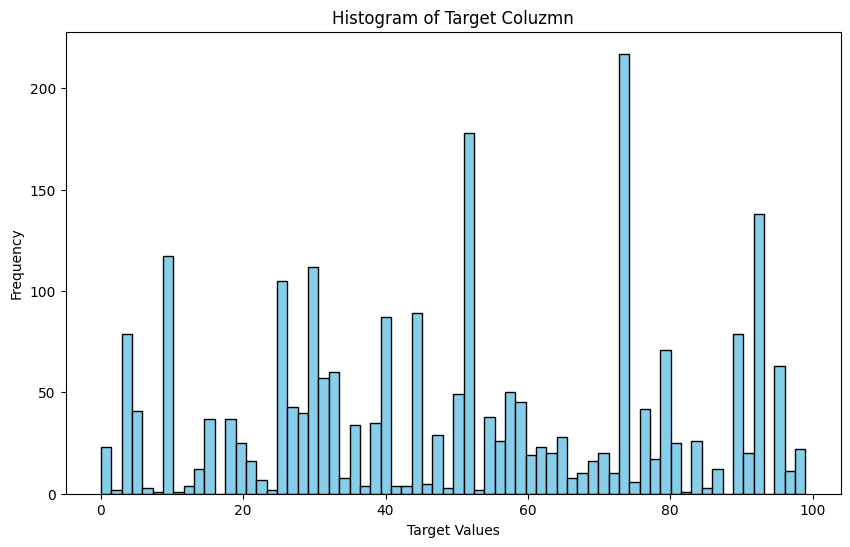

In [84]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Coluzmn')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [85]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,5922,19,3,19,19,0.414989,0.302687,0.108428,0.849232,False,True,True,True,True
1,22669,78,18,91,91,0.933317,0.631076,0.553040,0.721982,False,False,False,True,True
2,116,68,90,68,68,0.845066,0.999334,0.994981,0.999353,False,True,True,True,True
3,9444,29,44,29,29,0.675621,0.281828,0.347960,0.922972,False,True,True,True,True
4,28751,89,90,41,41,0.991744,0.597838,0.539532,0.993491,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,40350,14,92,7,41,0.684006,0.373521,0.267852,0.608862,False,False,False,True,True
9996,43552,34,4,6,6,0.459673,0.517323,0.381703,0.814097,False,False,False,True,True
9997,34078,7,92,7,83,0.987406,0.633029,0.593678,0.995237,False,True,False,True,True
9998,21923,49,95,49,49,0.568201,0.953556,0.787380,0.967790,False,True,True,True,True


In [86]:
df_results_v[(df_results_v['Softmax_decision']<0.9)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,5922,19,3,19,19,0.414989,0.302687,0.108428,0.849232,False,True,True,True,True
1,22669,78,18,91,91,0.933317,0.631076,0.553040,0.721982,False,False,False,True,True
9,23842,3,3,21,3,0.942134,0.493064,0.500778,0.619000,True,False,True,True,False
10,22795,21,72,15,3,0.335542,0.232077,0.213620,0.756756,False,False,False,False,True
16,43300,73,95,30,30,0.999114,0.999999,0.759534,0.730698,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9993,13933,44,44,26,44,0.998915,0.933931,0.480489,0.628849,True,False,True,True,False
9994,21148,43,3,43,21,0.677335,0.662817,0.343254,0.696142,False,True,False,True,True
9995,40350,14,92,7,41,0.684006,0.373521,0.267852,0.608862,False,False,False,True,True
9996,43552,34,4,6,6,0.459673,0.517323,0.381703,0.814097,False,False,False,True,True


In [87]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])&(df_results_v['Decision']==True)&(df_results_v['Match_F']==True)&(df_results_v['Match_T']==False)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
9,23842,3,3,21,3,0.942134,0.493064,0.500778,0.619000,True,False,True,True,False
53,40393,80,80,74,80,0.441491,0.330322,0.239430,0.588710,True,False,True,True,False
68,5292,3,3,21,21,0.925381,0.999765,0.992623,0.991725,True,False,False,True,False
99,41737,80,80,34,80,0.934790,0.386611,0.315933,0.535971,True,False,True,True,False
112,3000,73,73,91,91,0.668283,0.920156,0.482886,0.676690,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9863,15541,57,57,0,0,0.964264,0.672166,0.408795,0.959482,True,False,False,True,False
9953,1328,98,98,26,26,0.468565,0.718922,0.563001,0.981240,True,False,False,True,False
9975,41467,90,90,17,17,0.999521,0.644306,0.748537,0.989974,True,False,False,True,False
9982,18383,10,10,23,23,0.574463,0.257046,0.201898,0.600969,True,False,False,True,False


In [88]:
df=df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]
target_counts = df['Target'].value_counts()
target_counts 

92    62
44    53
40    52
90    51
52    50
      ..
85     3
71     3
82     2
58     2
60     1
Name: Target, Length: 96, dtype: int64

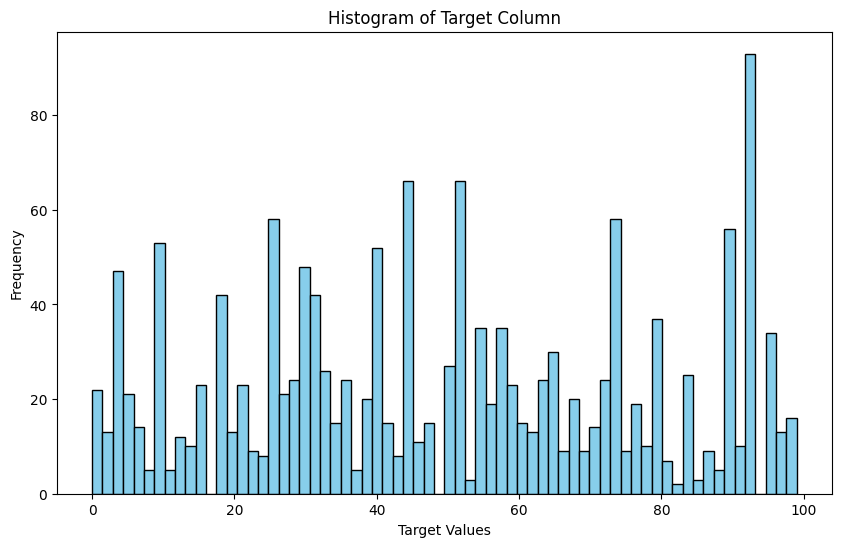

In [89]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [90]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision,decision_mode='softmax_tf')
total_train_loss,total_train_accu,sum_F,sum_T


(9.68355364112854, 0.665475, 15101, 24899)

In [91]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision,decision_mode='softmax_tf')
total_valid_loss,total_valid_accu,sum_F,sum_T

(12.460824074554443, 0.4672, 4330, 5670)

In [92]:
#全部模型裝在一起的表現
def total_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision,decision_mode=None):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    model_0.eval()
    model_T.eval()
    model_F.eval()
    model_decision.eval()

    with torch.no_grad():
        for data,target,decision_target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            


            for d,t in zip(data,target):
                out_d=model_decision(d.unsqueeze(0))
                _, pred= torch.max(out_d, dim = 1)

                if(decision_mode=='model'):
                    if(pred==0):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1
                elif(decision_mode=='softmax_0'):
                    out_0=model_0(d.unsqueeze(0))
                    softmax_0 = torch.max(torch.softmax(out_0, dim=1)).item()

                    if(softmax_0<0.8):
                        outputs.append(out_F)
                        sum_F+=1
                    else:
                        outputs.append(out_T)
                        sum_T+=1

                elif(decision_mode=='softmax_tf'):
                    out_F=model_F(d.unsqueeze(0))
                    out_T=model_T(d.unsqueeze(0))

                    softmax_F = torch.max(torch.softmax(out_F, dim=1)).item()
                    softmax_T = torch.max(torch.softmax(out_T, dim=1)).item()
                    if(softmax_F>softmax_T):
                        outputs.append(out_F)
                        sum_F+=1
                    else:
                        outputs.append(out_T)
                        sum_T+=1

                elif(decision_mode=='model+softmax_d'):

                    out_F=model_F(d.unsqueeze(0))
                    out_T=model_T(d.unsqueeze(0))

                    softmax_d = torch.max(torch.softmax(out_d, dim=1)).item()

                    softmax_F = torch.max(torch.softmax(out_F, dim=1)).item()
                    softmax_T = torch.max(torch.softmax(out_T, dim=1)).item()
                    if(softmax_d<0.9):
                        if(softmax_F>softmax_T):
                            outputs.append(out_F)
                            sum_F+=1
                        else:
                            outputs.append(out_T)
                            sum_T+=1
                    else:
                        if(pred==0):
                            outputs.append(model_F(d.unsqueeze(0)))
                            sum_F+=1
                        else:
                            outputs.append(model_T(d.unsqueeze(0)))
                            sum_T+=1

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T


In [93]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision,decision_mode='model+softmax_d')
total_train_loss,total_train_accu,sum_F,sum_T

(3.3590039496183395, 0.8249, 11954, 28046)

In [94]:

total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision,decision_mode='model+softmax_d')
total_valid_loss,total_valid_accu,sum_F,sum_T

(6.132302611160278, 0.5893, 3161, 6839)